# Set up 

In [1]:
from modeling import *
import matplotlib.pyplot as plt
from plot_utils import *

In [2]:
# %cd /oscar/data/epavlick/zyang220/lm_vector_arithmetic
!pwd

/oscar/data/epavlick/zyang220/lm_vector_arithmetic


In [3]:
!nvidia-smi

Sun Mar  9 18:08:50 2025       
+---------------------------------------------------------------------------------------+
| NVIDIA-SMI 535.129.03             Driver Version: 535.129.03   CUDA Version: 12.2     |
|-----------------------------------------+----------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id        Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |         Memory-Usage | GPU-Util  Compute M. |
|                                         |                      |               MIG M. |
|=========================================+======================+======================|
|   0  NVIDIA L40S                    On  | 00000000:61:00.0 Off |                    0 |
| N/A   33C    P0              80W / 350W |   2202MiB / 46068MiB |      0%      Default |
|                                         |                      |                  N/A |
+-----------------------------------------+----------------------+--

In [4]:
device = get_device()
device

'cuda:0'

In [5]:
tokenizer = AutoTokenizer.from_pretrained("EleutherAI/gpt-j-6b")
model = AutoModelForCausalLM.from_pretrained("EleutherAI/gpt-j-6b", 
    revision='float16', torch_dtype=torch.float16,).to(device)
model = model.float()
wrapper = GPTJWrapper(model, tokenizer)

Some weights of the model checkpoint at EleutherAI/gpt-j-6b were not used when initializing GPTJForCausalLM: ['transformer.h.0.attn.bias', 'transformer.h.0.attn.masked_bias', 'transformer.h.1.attn.bias', 'transformer.h.1.attn.masked_bias', 'transformer.h.10.attn.bias', 'transformer.h.10.attn.masked_bias', 'transformer.h.11.attn.bias', 'transformer.h.11.attn.masked_bias', 'transformer.h.12.attn.bias', 'transformer.h.12.attn.masked_bias', 'transformer.h.13.attn.bias', 'transformer.h.13.attn.masked_bias', 'transformer.h.14.attn.bias', 'transformer.h.14.attn.masked_bias', 'transformer.h.15.attn.bias', 'transformer.h.15.attn.masked_bias', 'transformer.h.16.attn.bias', 'transformer.h.16.attn.masked_bias', 'transformer.h.17.attn.bias', 'transformer.h.17.attn.masked_bias', 'transformer.h.18.attn.bias', 'transformer.h.18.attn.masked_bias', 'transformer.h.19.attn.bias', 'transformer.h.19.attn.masked_bias', 'transformer.h.2.attn.bias', 'transformer.h.2.attn.masked_bias', 'transformer.h.20.attn.bi

In [6]:
#first we will store the normal FFN layers so that we can restore the model later
mlps = []
for i in range(len(wrapper.model.transformer.h)):
    mlps.append(wrapper.model.transformer.h[i].mlp)

# func

In [7]:
def tokenize(text):
    inp_ids = wrapper.tokenize(text)
    str_toks = wrapper.list_decode(inp_ids[0])
    return inp_ids, str_toks

In [8]:
def reset_mlps():
    for i in range(len(wrapper.model.transformer.h)):
        wrapper.model.transformer.h[i].mlp = mlps[i]

In [9]:
def o_intervention(o_func, layer_start, layer_end=model.config.n_layer):
    for i in range(layer_start, layer_end): #Note: change these to change which layers are intervened on
        wrapper.model.transformer.h[i].mlp = LambdaLayer(lambda x: o_func) #instead of outputting FFN(x), output o_func

In [10]:
def reset_mask(wrapper):
    headmask = torch.ones(len(wrapper.model.transformer.h), wrapper.model.config.n_head)
    return headmask

## plot

In [11]:
def final_rrs_histogram(final_rrs):
    #plt.figure(figsize=(3, 2))
    plt.hist(final_rrs, bins=np.arange(0, 1.1, 0.05), color=[0.12710496, 0.64018454, 0.60749712, 1.])
    plt.xlabel('intervention final layer reciprocal rank', fontsize=10)
    plt.ylabel('Frequency', fontsize=10)
    #plt.title('Intervention Final Reciprocal Ranks')
    #plt.show()
    

In [12]:
def plot_intervention(word_answer, text, mlp_O, layer_start, layer_end=model.config.n_layer):
    
    tokens_answer = wrapper.tokenizer.encode(f"{word_answer}")
    if len(tokens_answer) > 1:
        print(f'"{word_answer}"', tokens_answer, [wrapper.tokenizer.decode([t]) for t in tokens_answer])

    reset_mlps()
    ids, toks = tokenize(text)
    cntrl_logits = wrapper.get_layers(ids)
    cntrl_rrs = wrapper.rr_per_layer(cntrl_logits, word_answer)

    o_intervention(mlp_O.unsqueeze(0), layer_start=layer_start, layer_end=layer_end)

    interv_logits = wrapper.get_layers(ids)
    interv_rrs = wrapper.rr_per_layer(interv_logits, word_answer)

    plot_rrs_before_and_after_intervention(cntrl_rrs, interv_rrs, title=text, label=word_answer, layer_start=layer_start, layer_end=layer_end)

In [61]:
def plot_accuracy(correct_cntrl_accuracy, correct_interv_accuracy):
    """
    Parameters:
        correct_cntrl_accuracy: float, accuracy scores for control condition
        correct_interv_accuracy: float, accuracy scores for intervention condition
    """
    bars = plt.bar(['Control', 'Intervention'], [correct_cntrl_accuracy, correct_interv_accuracy])
    plt.ylim(0, 1.1)
    plt.ylabel('Accuracy', fontsize=10)
    
    # Add text annotions above each bar
    for bar in bars:
        height = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.2f}',
                ha='center', va='bottom')
    #plt.show()

In [91]:
def plot_intervention_mean(word_answers, word_args, mlp_O, 
    layer_start, layer_end=model.config.n_layer
):
    """
    Parameters:
    word_answers: list of answers 
    word_args: list of arguments 
    mlp_O: mlp output vector to use for intervention 
    layer_start: layer to start intervening on 
    layer_end: layer to end intervening before (default is n_layer),  not including the layer_end 
    """
    interv_rrs = np.empty((len(word_answers), wrapper.model.config.n_layer+1))
    interv_rrs_arg = np.empty((len(word_answers), wrapper.model.config.n_layer+1))
    cntrl_rrs = np.empty((len(word_answers), wrapper.model.config.n_layer+1))
    cntrl_pred_idxs = np.empty((len(word_answers)), dtype=int)
    interv_pred_idxs = np.empty((len(word_answers)), dtype=int)
    answer_ids = []

    for i, (word_arg, word_answer) in enumerate(zip(word_args, word_answers)):
        text = f"returning ensus machine{word_arg} returning ensus machine{word_arg} returning ensus machine"
        tokens_answer = wrapper.tokenizer.encode(f"{word_answer}")
        answer_ids.append(tokens_answer[0])
        if len(tokens_answer) > 1:
            print(f'"{word_answer}"', tokens_answer, [wrapper.tokenizer.decode([t]) for t in tokens_answer])

        reset_mlps()
        ids, toks = tokenize(text)
        cntrl_logit = wrapper.get_layers(ids)
        cntrl_rr = wrapper.rr_per_layer(cntrl_logit, word_answer)

        o_intervention(mlp_O.unsqueeze(0), layer_start=layer_start, layer_end=layer_end)
        interv_logit = wrapper.get_layers(ids)

        interv_rr = wrapper.rr_per_layer(interv_logit, word_answer)
        interv_rr_arg = wrapper.rr_per_layer(interv_logit, word_arg)

        # reciprocal ranks  
        interv_rrs[i] = interv_rr
        cntrl_rrs[i] = cntrl_rr
        interv_rrs_arg[i] = interv_rr_arg

        # prediction 
        cntrl_pred_idx = cntrl_logit[-1].argmax(dim=-1)
        interv_pred_idx = interv_logit[-1].argmax(dim=-1)
        cntrl_pred_idxs[i] = cntrl_pred_idx
        interv_pred_idxs[i] = interv_pred_idx

    # calculate the mean of the rrs
    cntrl_rrs_mean = np.mean(cntrl_rrs, axis=0)
    interv_rrs_mean = np.mean(interv_rrs, axis=0)
    interv_rrs_arg_mean = np.mean(interv_rrs_arg, axis=0)
    final_rrs = interv_rrs[:, -1]
    final_rrs_below = [word_args[i] for i in range(len(final_rrs)) if final_rrs[i] < 0.95]
    final_rrs_above = [word_args[i] for i in range(len(final_rrs)) if final_rrs[i] >= 0.95]
    print(f"final rrs below 0.95: {final_rrs_below}")
    print(f"final rrs above 0.95: {final_rrs_above}")

    # accuracy 
    #answer_ids = tokenizer.encode(word_answers)
    correct_cntrl = [i for i in range(len(cntrl_pred_idxs)) if cntrl_pred_idxs[i] == answer_ids[i]]
    correct_interv = [i for i in range(len(interv_pred_idxs)) if interv_pred_idxs[i] == answer_ids[i]]
    correct_cntrl_accuracy = len(correct_cntrl) / len(answer_ids)
    correct_interv_accuracy = len(correct_interv) / len(answer_ids)
    wrong_interv_words = [word_args[i] for i in range(len(interv_pred_idxs)) 
        if interv_pred_idxs[i] != answer_ids[i]]
    correct_interv_words = [word_args[i] for i in correct_interv]
    print(f"wrong interv words: {wrong_interv_words}")
    print(f"correct interv words: {correct_interv_words}")

    # plot 
    fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(9, 4))
    fig.suptitle(f"Intervention", fontsize=12)

    plt.sca(ax1)
    plot_rrs_before_and_after_intervention(cntrl_rrs_mean, interv_rrs_mean, 
        layer_start=layer_start, layer_end=layer_end, mean=True,
    )
    plt.sca(ax2)
    plot_rrs_aug_answer(wrapper, aug_rrs=interv_rrs_arg_mean, answer_rrs=interv_rrs_mean,
        layer_start=layer_start, layer_end=layer_end, mean=True,
    )
    plt.sca(ax3) 
    final_rrs_histogram(final_rrs)
    plt.sca(ax4)
    plot_accuracy(correct_cntrl_accuracy, correct_interv_accuracy)
    
    plt.tight_layout()
    

In [90]:
def plot_rrs_aug_answer(wrapper, aug_rrs, answer_rrs, mean=False,
    layer_start=None, layer_end=None,
):
    if layer_end is None:
        layer_end = wrapper.model.config.n_layer
        
    colors = [
        [0.12710496, 0.44018454, 0.70749712, 1.        ], #Arg
        [0.12710496, 0.64018454, 0.60749712, 1.        ], #Answer
    ]
    #plt.title(title, fontsize=18)
    plt.xticks(np.arange(wrapper.model.config.n_layer), np.arange(wrapper.model.config.n_layer), rotation=90)
    plt.plot(aug_rrs[1:], label='augument', marker='o', color=colors[0]) #Why [1:]? rrs[0] is the embedding table step
    plt.plot(answer_rrs[1:], label='answer', marker='o', color=colors[1]) #Why [1:]? rrs[0] is the embedding table step
    if layer_start is not None:
        plt.axvspan(layer_start, layer_end-1, facecolor='.92')
    plt.legend(fontsize=8)
    plt.xlabel("Layer", fontsize=10)
    plt.ylabel("Mean Reciprocal Rank" if mean else "Reciprocal Rank", fontsize=10)
    plt.yticks([0.,.2,.4,.6,.8,1.], ['0.0','0.2','0.4','0.6','0.8','1.0'])
    plt.tight_layout()

In [73]:
def plot_rrs_before_and_after_intervention(before_rrs, after_rrs, 
    title='', label='', layer_start=None, layer_end=model.config.n_layer, mean=False):
    colors = [
        [0, 0, 0, 1], # zero shot
        [0.12710496, 0.64018454, 0.60749712, 1.        ], # + mlp_O
    ]
    plt.title(title, fontsize=10)
    plt.xticks(np.arange(model.config.n_layer), np.arange(model.config.n_layer), rotation=90)
    plt.plot(before_rrs[1:], label=f'{label}: zero shot', marker='o', color=colors[0]) #Why [1:]? rrs[0] is the embedding table step
    plt.plot(after_rrs[1:], label=f'{label}:'+' + mlp_O', marker='o', color=colors[1]) #Why [1:]? rrs[0] is the embedding table step

    if layer_start is not None:
        plt.axvspan(layer_start, layer_end-1, facecolor='.92')
    plt.legend(fontsize=8)
    plt.xlabel("Layer", fontsize=10)
    plt.ylabel("Mean Reciprocal Rank" if mean else "Reciprocal Rank", fontsize=10)
    plt.ylim(0, 1.1)
    plt.yticks([0.,.2,.4,.6,.8,1.], ['0.0','0.2','0.4','0.6','0.8','1.0'])
    plt.tight_layout()

# Capital

In [8]:
poland_text="""Q: What is the capital of France?
A: Paris
Q: What is the capital of Poland?
A:"""

poland_ids, pol_toks = wrapper.tokenize_ids_str(poland_text)
print(poland_ids)
print(pol_toks)

tensor([[   48,    25,  1867,   318,   262,  3139,   286,  4881,    30,   198,
            32,    25,  6342,   198,    48,    25,  1867,   318,   262,  3139,
           286, 12873,    30,   198,    32,    25]], device='cuda:0')
['Q', ':', ' What', ' is', ' the', ' capital', ' of', ' France', '?', '\n', 'A', ':', ' Paris', '\n', 'Q', ':', ' What', ' is', ' the', ' capital', ' of', ' Poland', '?', '\n', 'A', ':']


In [9]:
logits = wrapper.get_layers(poland_ids) # get the decoded logits from each layer 
wrapper.print_top(logits[1:]) #skip the embedding layer

0 signed Franco also solemn still)' —commit MaddBBC
1  Sin Madd Phys Lostsigned — Array Ang SPD Alan
2  Phys Madd Polit Included Former Hey Bren Birth Malt All
3  Included Phys Rum Yes Died claims Ben Chal All "
4  " The Most Yes Due Phys Only All None It
5  Most Yes " The Phys Probably Modern Due Hang Physical
6  The Yes " � < Most Only yes None First
7  Yes The Same Hol " Our None Most Well Mir
8  Hol The Yes Santa " Be Blue yes Win Te
9  Paris Tour Athens Port Lisbon The Mexico Ge London Dublin
10  Hol Mir Win Hang The Ge Place City Be Pra
11  San Phoenix City North The city Republic London Jerusalem State
12  Poland Warsaw Budapest Moscow Berlin Vienna Kiev Lisbon Jerusalem Prague
13  Warsaw Budapest Moscow Paris Poland Berlin London Jerusalem Madrid Vienna
14  Warsaw Budapest London Jerusalem Moscow Paris Berlin Prague Madrid Lisbon
15  Warsaw London Paris Budapest Jerusalem Moscow Berlin Rome Lisbon Madrid
16  Warsaw Poland Polish Budapest Prague Moscow Poles Berlin Helsinki Brus

## arg answer x plot (single run)

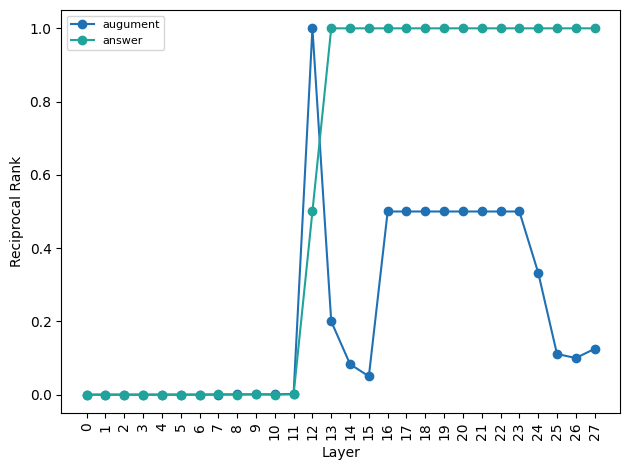

In [10]:
# get rr per layer 
aug_rrs = wrapper.rr_per_layer(logits, ' Poland')
answer_rrs = wrapper.rr_per_layer(logits, ' Warsaw')

# plot 
plot_rrs_aug_answer(wrapper, aug_rrs, answer_rrs)

## mlp_O

In [11]:
wrapper.add_hooks()
out = wrapper.model(input_ids = poland_ids, output_hidden_states=True) #run it again to activate hooks
#get the FFN output update at layer 13
o_city = wrapper.model.activations_['mlp_13']

In [12]:
"""
We can decode at the residual stream between the attention and FFN to show that 
it is the FFN update that updates from Poland to Warsaw, but a slightly easier way to do this is to
subtract the FFN update that was applied at layer 13 to show the intermediate residual stream state
(i.e., between the attention and FFN)
"""

logits = out.logits
hidden_states = out.hidden_states
hidden_states = list(hidden_states)[1:] #skip the embedding layer to stay consistent with our indexing
print("len hidden_states: ", len(hidden_states)) #

layer_logits = wrapper.layer_decode(hidden_states)
layer_logits = torch.stack(layer_logits).squeeze(-1)
print("Original top tokens at layer 13")
wrapper.print_top(layer_logits[13].unsqueeze(0))

o_city = o_city.to(hidden_states[13].device)
hidden_states[13]-=o_city 
layer_logits = wrapper.layer_decode(hidden_states)
layer_logits = torch.stack(layer_logits).squeeze(-1)
print("After subtracting mlp_13 (o_city)")
wrapper.print_top(layer_logits[13].unsqueeze(0))

#Now we can see that the prediction at layer 13 has gone from Warsaw to Poland (or something else)

len hidden_states:  28
Original top tokens at layer 13
0  Warsaw Budapest Moscow Paris Poland Berlin London Jerusalem Madrid Vienna
After subtracting mlp_13 (o_city)
0  Budapest Warsaw Poland Paris Moscow Jerusalem Berlin cities Athens London


In [13]:
"""
before showing that mlp_13 promotes capital cities in general, we can show that mlp_13 can interact with other layers
within the same input

We can use o_city to manipulate the other layers that are either in argument formation (representing " Poland")
or in saturation (representing " Warsaw"). We can try to flip these states so that all of the arguments become
the output " Warsaw" and the saturated states go back to the argument " Poland"
""" 

out = wrapper.model(input_ids = poland_ids, output_hidden_states=True) #run it again to activate hooks
logits = out.logits
hidden_states = out.hidden_states
hidden_states = list(hidden_states)[1:]

layer_logits = wrapper.layer_decode(hidden_states)
layer_logits = torch.stack(layer_logits).squeeze(-1)

print("Original: most likely tokens starting at layer 8:")
wrapper.print_top(layer_logits[8:])

print("----")
#We can add o_city to go from Poland to Warsaw, and subtract to go from Warsaw to Poland

#We find that when we intervene at a single later layer (>15), we have to scale the vector up
#and for some reason, it tends to need to scale down at the last layer
#in the paper, this is partly why we apply the interventions at multiple layers in a row, so that
#it accumulates in the forward pass.
hidden_states[9]+=o_city
hidden_states[10]+=o_city
hidden_states[11]+=o_city
hidden_states[12]+=o_city
hidden_states[13]-=o_city 
hidden_states[14]-=2*o_city 
hidden_states[15]-=3*o_city
hidden_states[16]-=4*o_city 
#hidden_states[21]-=.9*o_city #The last layer can be weird. Play around with this scaling factor to see

layer_logits = wrapper.layer_decode(hidden_states)
layer_logits = torch.stack(layer_logits).squeeze(-1)
#As you can see, we can flip every token from Warsaw to Poland or vice versa 
#except for layer 15 with +/- o_city, with some scaling for the later layers
print("After intervention: Most likely tokens starting at layer 9:")
wrapper.print_top(layer_logits[9:])

Original: most likely tokens starting at layer 8:
0  Hol The Yes Santa " Be Blue yes Win Te
1  Paris Tour Athens Port Lisbon The Mexico Ge London Dublin
2  Hol Mir Win Hang The Ge Place City Be Pra
3  San Phoenix City North The city Republic London Jerusalem State
4  Poland Warsaw Budapest Moscow Berlin Vienna Kiev Lisbon Jerusalem Prague
5  Warsaw Budapest Moscow Paris Poland Berlin London Jerusalem Madrid Vienna
6  Warsaw Budapest London Jerusalem Moscow Paris Berlin Prague Madrid Lisbon
7  Warsaw London Paris Budapest Jerusalem Moscow Berlin Rome Lisbon Madrid
8  Warsaw Poland Polish Budapest Prague Moscow Poles Berlin Helsinki Brussels
9  Warsaw Poland Polish Budapest Prague Moscow Berlin Helsinki Brussels London
10  Warsaw Poland Polish Budapest Moscow Prague Berlin Helsinki London Kiev
11  Warsaw Poland Polish Budapest Prague Moscow Berlin Helsinki Kiev Poles
12  Warsaw Poland Polish Budapest Prague Moscow BerlinWars Helsinki Brussels
13  Warsaw Poland Polish Budapest Berlin Mosc

In [14]:
"""
Next we will show that o_city works to promote other capital cities in totally different contexts
e.g., transforming China into Beijing where the context does not cue the model that Beijing might be important

We will perform the o vector intervention described in the paper, in which we replace FFN blocks entirely,
substituting their updates with the precomputed o vector (in this case o_city)
"""

'\nNext we will show that o_city works to promote other capital cities in totally different contexts\ne.g., transforming China into Beijing where the context does not cue the model that Beijing might be important\n\nWe will perform the o vector intervention described in the paper, in which we replace FFN blocks entirely,\nsubstituting their updates with the precomputed o vector (in this case o_city)\n'

In [15]:
"""
First, let's show what we are trying to do:
given some repeating pattern of random tokens with some subject token mixed in, we
can take advantage of the fact that when predicting the next instance of the subject token,
the model will represent that subject token in some middle layer, giving us a chance to intervene
"""

china_text = "table mug free China table mug free China table mug free"
wrapper.reset_mlps(mlps)
china_ids, china_toks = wrapper.tokenize_ids_str(china_text)
cntrl_china_logits = wrapper.get_layers(china_ids)
#Let's just look at the most likely token per layer to make it clear
wrapper.print_top(cntrl_china_logits, k=1)
#as you can see, the prediction is already China by layer 17, we can introduce an intervention to add o_city to some
#range of these layers to try to transform it into Beijing
#we will essentially perform the operation China+o_city=Beijing
#where o_city is the FFN update that had originally transformed Poland into Warsaw

0 JSON
1 zed
2 bies
3 bies
4 bies
5 bies
6 bies
7 .
8  Community
9 .
10 .
11 .
12 bies
13 bies
14 bies
15 bies
16 <|endoftext|>
17  China
18  China
19  China
20  China
21  China
22  China
23  China
24  China
25  China
26  China
27  China
28  China


## intervention (individual)

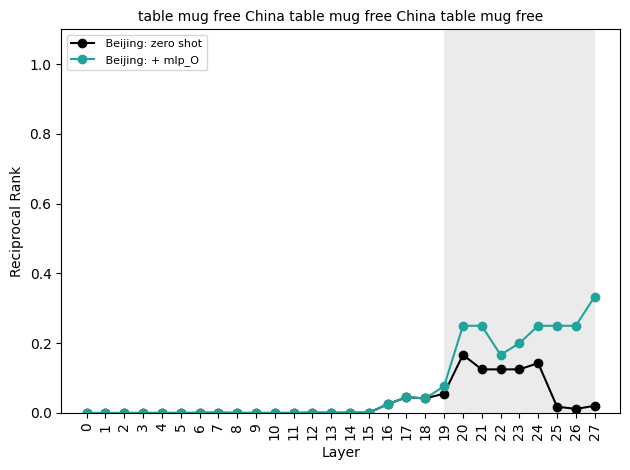

In [16]:
#For this result we will plot the reciprocal ranks of the tokens we are interested in within the vocab distributions
#These tokens are the original country (argument: China) and the corresponding capital (output: Beijing)
word_arg = " China"
word_answer = " Beijing"
text = f"table mug free{word_arg} table mug free{word_arg} table mug free"
layer_idx = 19
plot_intervention(wrapper, mlps, word_answer, text, o_city, layer_start=layer_idx)

#You should see that even on this nonsense input, Beijing gets promoted from very low in the vocab to the top spot
#in the last layer

## saved 0

In [17]:
path = '/oscar/data/epavlick/zyang220/lm_vector_arithmetic/'
paper_o_city = torch.tensor(np.load(path +'ovectors/gptj/city_capital_o13_gptj.npy')).squeeze(0)

print(paper_o_city[:10])
print(o_city[:10])
print(paper_o_city.device)
print(o_city.device)

tensor([-0.2072, -0.0791, -0.2549, -0.0080, -0.5864,  0.4346,  0.0073, -0.6646,
         0.0264,  0.2554], dtype=torch.float16)
tensor([-0.2072, -0.0803, -0.2574, -0.0104, -0.5868,  0.4364,  0.0074, -0.6658,
         0.0257,  0.2553], device='cuda:0')
cpu
cuda:0


In [18]:
if torch.equal(paper_o_city.to(device), o_city):
    print("paper_o_city and o_city are equal")
else:
    print("paper_o_city and o_city are not equal")
# calculate the cosine similarity between paper_o_city and o_city
cosine_similarity = torch.nn.functional.cosine_similarity(paper_o_city.to(device), o_city.to(device), dim=0)
print(f"Cosine similarity between paper_o_city and o_city: {cosine_similarity}")

paper_o_city and o_city are not equal
Cosine similarity between paper_o_city and o_city: 1.0000336170196533


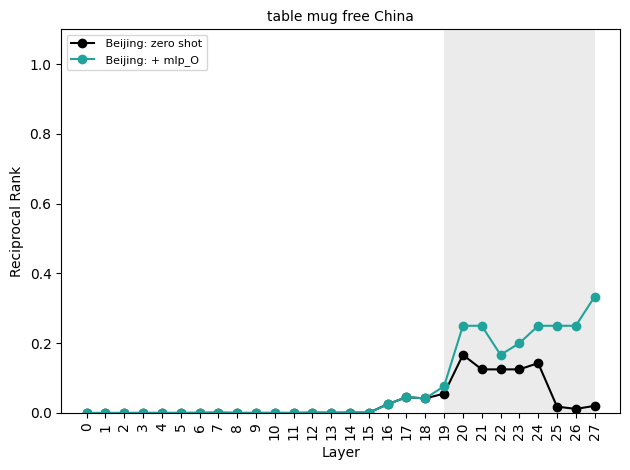

In [20]:
#For this result we will plot the reciprocal ranks of the tokens we are interested in within the vocab distributions
#These tokens are the original country (argument: China) and the corresponding capital (output: Beijing)
wrapper.reset_mlps(mlps)
layer_idx = 19

cntrl_rrs = wrapper.rr_per_layer(cntrl_china_logits, ' Beijing')

wrapper.o_intervention(paper_o_city.unsqueeze(0).to(device), layer_idx)

interv_china_logits = wrapper.get_layers(china_ids)
interv_rrs = wrapper.rr_per_layer(interv_china_logits, ' Beijing')

plot_rrs_before_and_after_intervention(wrapper, cntrl_rrs, 
    interv_rrs, ' '.join(china_text.split()[:4]), " Beijing", layer_start=layer_idx)
#You should see that even on this nonsense input, Beijing gets promoted from very low in the vocab to the top spot
#in the last layer

In [23]:
country_text = f"ada Middle Although Turkey ada Middle Although Turkey ada Middle Although"
wrapper.reset_mlps(mlps)
country_ids, country_toks = wrapper.tokenize_ids_str(country_text)
country_logits = wrapper.get_layers(country_ids)
#Let's just look at the most likely token per layer to make it clear
wrapper.print_top(country_logits, k=1)


0  Kiw
1 ts
2  still
3 ts
4 ts
5  she
6 ts
7  it
8 …
9 …
10 ...
11 ..."
12 ..."
13 ..."
14 ..."
15 ts
16 <|endoftext|>
17  Turkey
18  Turkey
19  Turkey
20  Turkey
21  Turkey
22  Turkey
23  Turkey
24  Turkey
25  Turkey
26  Turkey
27  Turkey
28  Turkey


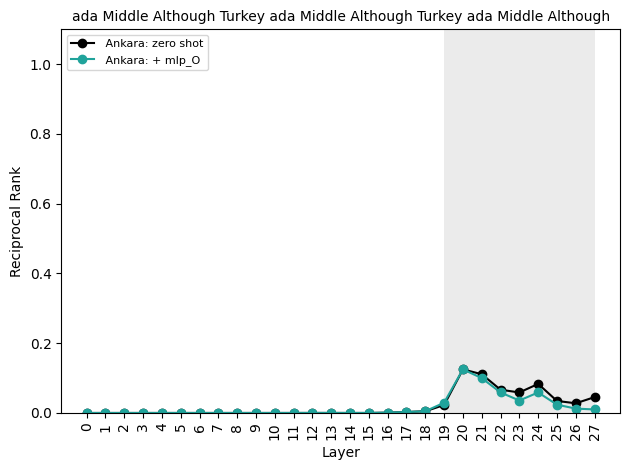

In [24]:
# We can repeat this with other examples as well. It might not always promote to most likely prediction in the last
# layer, but you should virtually always see an increase in the corresponding capital
word_arg = " Turkey"
word_answer = " Ankara"
text = f"ada Middle Although{word_arg} ada Middle Although{word_arg} ada Middle Although"
layer_idx = 19
plot_intervention(wrapper, mlps, word_answer, text, mlp_O=paper_o_city.to(device), layer_start=layer_idx)

# uppercasing

In [25]:
wrapper.reset_mlps(mlps)
wrapper.add_hooks()
colors_text = """Q: On the floor, I see a silver keychain, a red pair of sunglasses, a gold sheet of paper, a black dog leash, and a blue cat toy. What color is the keychain?
A: Silver
Q: On the table, you see a brown sheet of paper, a red fidget spinner, a blue pair of sunglasses, a teal dog leash, and a gold cup. What color is the sheet of paper?
A:"""

colors_ids, colors_toks = wrapper.tokenize_ids_str(colors_text)
colors_logits = wrapper.get_layers(colors_ids)[1:]

wrapper.print_top(colors_logits)

0 signed alsoserialcommit Franco still Madd solemn heir sensory
1  Sin Madd sometimes — Phys anonymously annexed SPDsigned Lost
2  Madd Phys Hey Bren Formerwb Polit draws Allinge
3  Most Phys All The Yes draws	 Ben Hey Still
4  " The Most All Yes None Oh � Due This
5  The Yes " Most This All Only � Oh None
6  Yes yes The � Only " See None First Most
7  Yes yes " same Same The answer Our First None
8  Yes yes Same same first The " Blue First �
9  Same Yes None same yes pink " Blue The first
10  Yes Same None Hidden same yes Again Blue none �
11  Yes Same None Hidden yes Blue blue same green Green
12  blue green white Blue brown pink yellow orange None purple
13  brown blue yellow white green orange purple pink black Brown
14  brown yellow blue white orange green purple color black gray
15  brown yellow blue white green orange purple gray pink Brown
16  brown Brown yellow bluebrown orange gray white purple black
17  brown yellow Brown orange blue whitebrown green gray purple
18  brown Br

## arg answer x plot (single run)

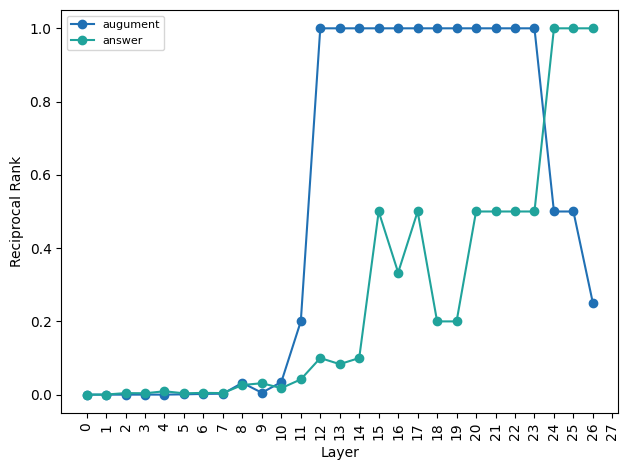

In [26]:
aug_rrs = wrapper.rr_per_layer(colors_logits, ' brown')
answer_rrs = wrapper.rr_per_layer(colors_logits, ' Brown')
plot_rrs_aug_answer(wrapper, aug_rrs, answer_rrs)

## Extract and compare mlp_O

In [27]:
o_upper = wrapper.model.activations_['mlp_25']
path = '/oscar/data/epavlick/zyang220/lm_vector_arithmetic/'
paper_o_upper = torch.tensor(np.load(path +'ovectors/gptj/uppercase_o25_gptj.npy')).squeeze(0)

In [43]:
print(o_upper[:15])
print(paper_o_upper[:15])
if torch.equal(o_upper.to(device), paper_o_upper.to(device)):
    print("o_upper and paper_o_upper are equal")
else:
    print("o_upper and paper_o_upper are not equal")
cosine_similarity = torch.nn.functional.cosine_similarity(o_upper, paper_o_upper.to(device), dim=0)
print(f"Cosine similarity between o_upper and paper_o_upper: {cosine_similarity}")

tensor([-0.8207, -0.1363, -0.2087, -0.1809,  0.4501,  0.1747,  0.5152,  0.5598,
         0.4914, -0.5374,  0.3674,  0.2989, -0.2171, -1.0986,  0.7460],
       device='cuda:0')
tensor([-0.8223, -0.1354, -0.2091, -0.1815,  0.4492,  0.1753,  0.5142,  0.5605,
         0.4910, -0.5356,  0.3647,  0.2991, -0.2157, -1.0986,  0.7461],
       dtype=torch.float16)
o_upper and paper_o_upper are not equal
Cosine similarity between o_upper and paper_o_upper: 1.0002224445343018


In [44]:
paper_o_upper.shape

torch.Size([4096])

In [46]:
test = torch.tensor(np.load(path +'ovectors/gptj/uppercase_o25_gptj.npy'))
test.ndim

2

: 

## individual egs

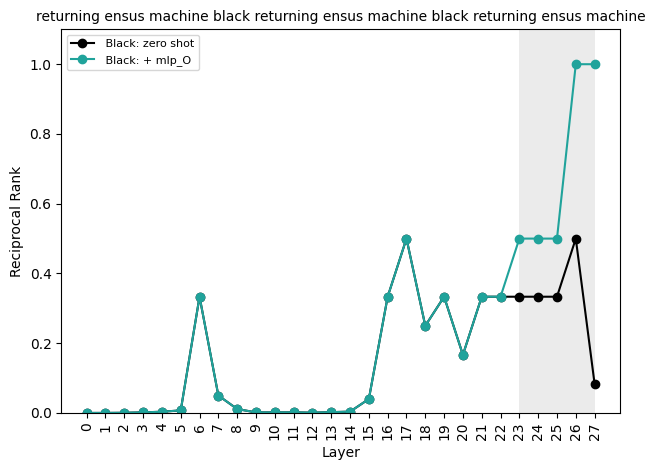

In [30]:
word_arg = " black"
word_answer = " Black"
text = f"returning ensus machine{word_arg} returning ensus machine{word_arg} returning ensus machine"
layer_idx = 23
plot_intervention(wrapper, mlps, word_answer, text, o_upper, layer_start=layer_idx)

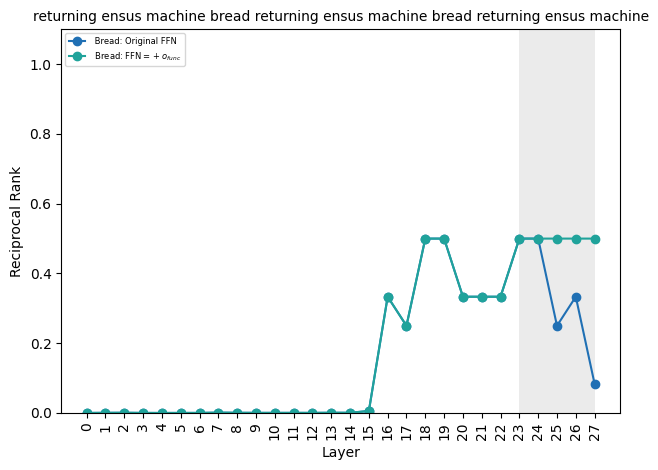

In [41]:
word_arg = " bread"
word_answer = " Bread"
text = f"returning ensus machine{word_arg} returning ensus machine{word_arg} returning ensus machine"
layer_idx = 23
plot_intervention(word_answer, text, mlp_O=o_upper, layer_start=layer_idx)

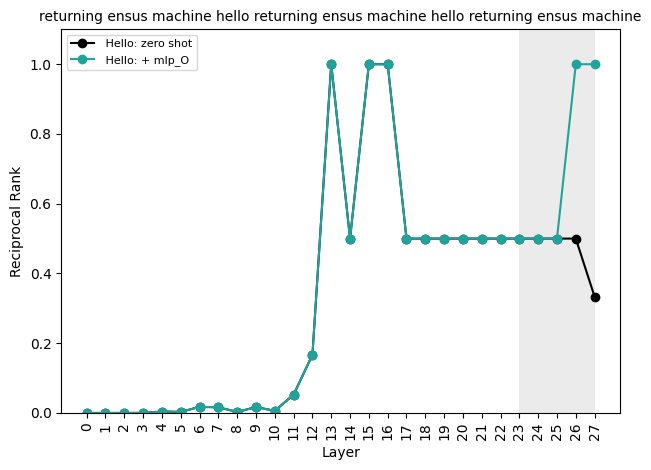

In [31]:
word_arg = " hello"
word_answer = " Hello"
text = f"returning ensus machine{word_arg} returning ensus machine{word_arg} returning ensus machine"
layer_idx = 23
plot_intervention(wrapper, mlps, word_answer, text, o_upper, layer_start=layer_idx)

" Crouch" [327, 48626] [' C', 'rouch']


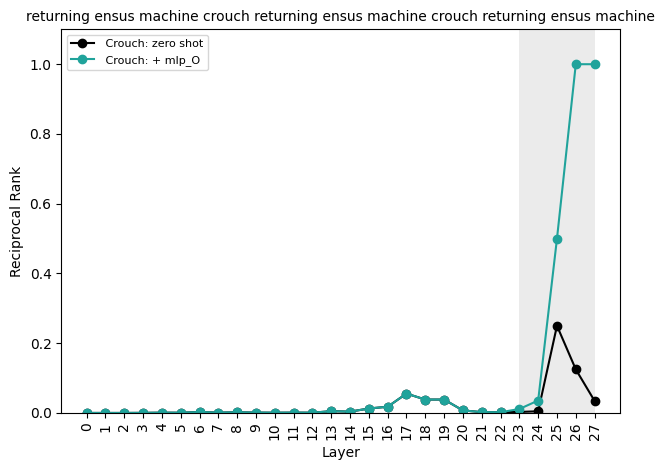

In [32]:
"""
Jack's comment:We find that the uppercasing o vector performs the most consistently out of the other two we tested.
One common failure point we saw for all three, however, is when either the argument or output tokens
are broken up into multiple tokens. For example, " crouch" is one token, but the capitalized form " Crouch"
is split into the tokens " C"+"rouch". It would be surprising if the relationship between " crouch" and " C" 
was encoded the same way as e.g., " bread" and " Bread", and we see that cases like these tend to react
more poorly to the intervention. Cases where a token maps to a single capital letter like these are particularly
challenging.
See Appendix
Jojo's comment: opposite of the paper or GPT-2 medium
"""
word_arg = " crouch"
word_answer = " Crouch"
text = f"returning ensus machine{word_arg} returning ensus machine{word_arg} returning ensus machine"
layer_idx = 23
plot_intervention(wrapper, mlps, word_answer, text, o_upper, layer_start=layer_idx)

" Crouch" [327, 48626] [' C', 'rouch']


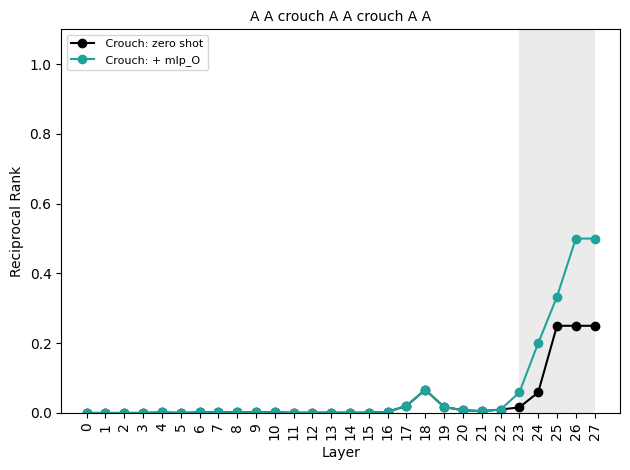

In [33]:
word_arg = " crouch"
word_answer = " Crouch"
text = f"A A{word_arg} A A{word_arg} A A"
layer_idx = 23
plot_intervention(wrapper, mlps, word_answer, text, o_upper, layer_start=layer_idx)

## mean non-color

mean over 15 runs
final rrs below 0.95: [' couch', ' cold', ' name', ' word', ' cup', ' man', ' bread', ' bus']
final rrs above 0.95: [' top', ' girl', ' hello', ' king', ' fruit', ' music', ' milk']
wrong interv words: [' couch', ' cold', ' name', ' word', ' cup', ' man', ' bread', ' bus']
correct interv words: [' top', ' girl', ' hello', ' king', ' fruit', ' music', ' milk']


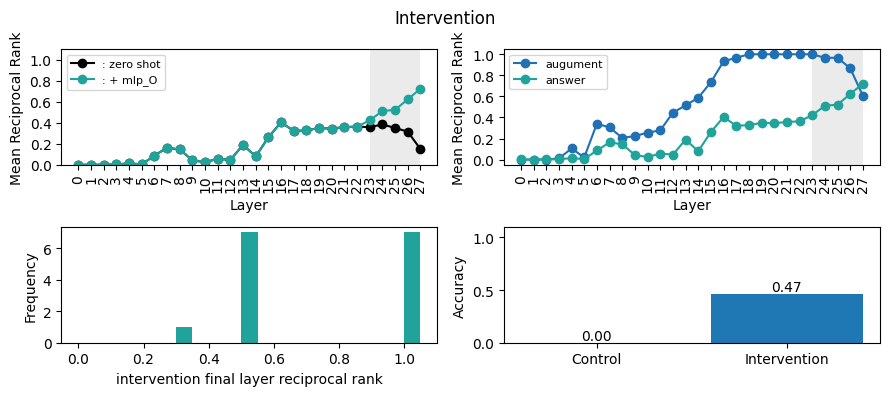

In [34]:
word_answers = [" Couch", " Top", " Girl", " Cold", " Name", " Hello", " Word", " Cup", " Man", " King", " Fruit", " Music", " Bread", " Milk", " Bus"]
word_args = [" couch", " top", " girl", " cold", " name", " hello", " word", " cup", " man", " king", " fruit", " music", " bread", " milk", " bus"]
print(f"mean over {len(word_answers)} runs")
plot_intervention_mean(wrapper, mlps, word_answers, word_args, o_upper, layer_start=23)

mean over 15 runs
final rrs below 0.95: [' couch', ' cold', ' name', ' word', ' cup', ' man', ' bread', ' bus']
final rrs above 0.95: [' top', ' girl', ' hello', ' king', ' fruit', ' music', ' milk']
wrong interv words: [' couch', ' cold', ' name', ' word', ' cup', ' man', ' bread', ' bus']
correct interv words: [' top', ' girl', ' hello', ' king', ' fruit', ' music', ' milk']


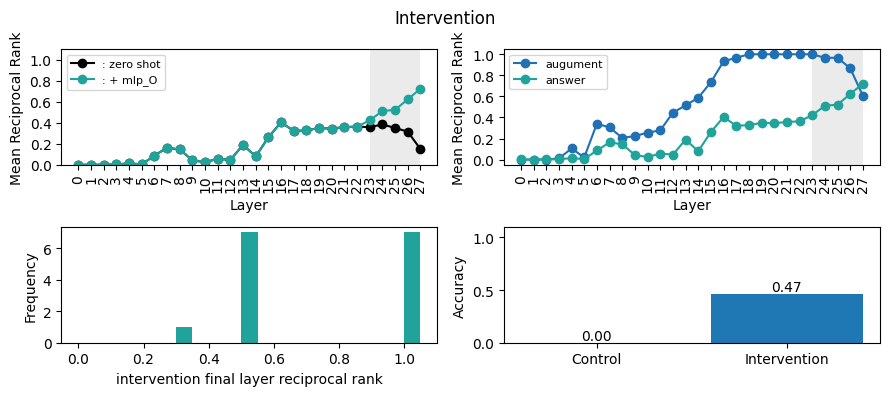

In [42]:
word_answers = [" Couch", " Top", " Girl", " Cold", " Name", " Hello", " Word", " Cup", " Man", " King", " Fruit", " Music", " Bread", " Milk", " Bus"]
word_args = [" couch", " top", " girl", " cold", " name", " hello", " word", " cup", " man", " king", " fruit", " music", " bread", " milk", " bus"]
print(f"mean over {len(word_answers)} runs")
plot_intervention_mean(wrapper, mlps, word_answers, word_args, mlp_O=paper_o_upper.to(device), layer_start=23)

mean over 15 runs
final rrs below 0.95: [' couch', ' girl', ' hello', ' word', ' fruit', ' bread', ' bus']
final rrs above 0.95: [' top', ' cold', ' name', ' cup', ' man', ' king', ' music', ' milk']
wrong interv words: [' couch', ' girl', ' hello', ' word', ' fruit', ' bread', ' bus']
correct interv words: [' top', ' cold', ' name', ' cup', ' man', ' king', ' music', ' milk']


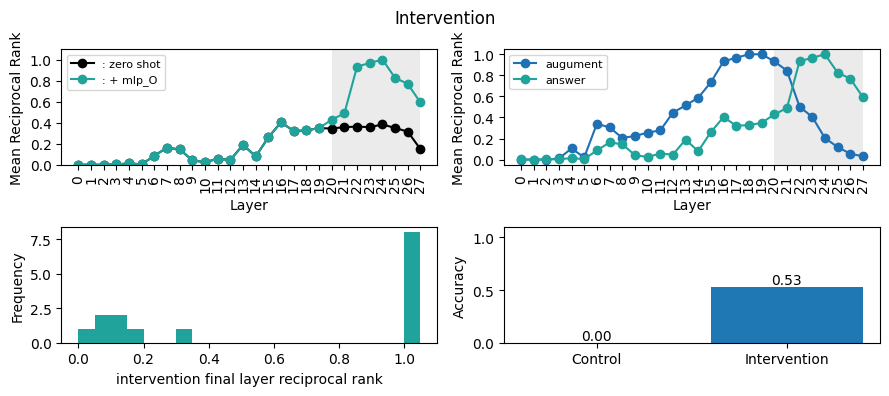

In [35]:
word_answers = [" Couch", " Top", " Girl", " Cold", " Name", " Hello", " Word", " Cup", " Man", " King", " Fruit", " Music", " Bread", " Milk", " Bus"]
word_args = [" couch", " top", " girl", " cold", " name", " hello", " word", " cup", " man", " king", " fruit", " music", " bread", " milk", " bus"]
print(f"mean over {len(word_answers)} runs")
plot_intervention_mean(wrapper, mlps, word_answers, word_args, o_upper, layer_start=20)

mean over 15 runs
final rrs below 0.95: [' name', ' man']
final rrs above 0.95: [' couch', ' top', ' girl', ' cold', ' hello', ' word', ' cup', ' king', ' fruit', ' music', ' bread', ' milk', ' bus']
wrong interv words: [' name', ' man']
correct interv words: [' couch', ' top', ' girl', ' cold', ' hello', ' word', ' cup', ' king', ' fruit', ' music', ' bread', ' milk', ' bus']


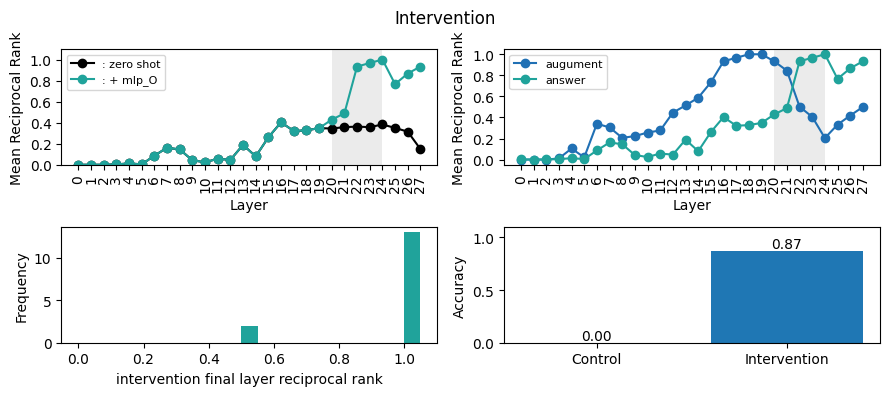

In [36]:
word_answers = [" Couch", " Top", " Girl", " Cold", " Name", " Hello", " Word", " Cup", " Man", " King", " Fruit", " Music", " Bread", " Milk", " Bus"]
word_args = [" couch", " top", " girl", " cold", " name", " hello", " word", " cup", " man", " king", " fruit", " music", " bread", " milk", " bus"]
print(f"mean over {len(word_answers)} runs")
plot_intervention_mean(wrapper, mlps, word_answers, word_args, o_upper, layer_start=20, layer_end=25)

## mean color 

mean over 14 runs


final rrs below 0.95: [' cardinal']
final rrs above 0.95: [' red', ' blue', ' green', ' purple', ' yellow', ' orange', ' pink', ' brown', ' black', ' white', ' gray', ' gold', ' silver']
wrong interv words: [' cardinal']
correct interv words: [' red', ' blue', ' green', ' purple', ' yellow', ' orange', ' pink', ' brown', ' black', ' white', ' gray', ' gold', ' silver']


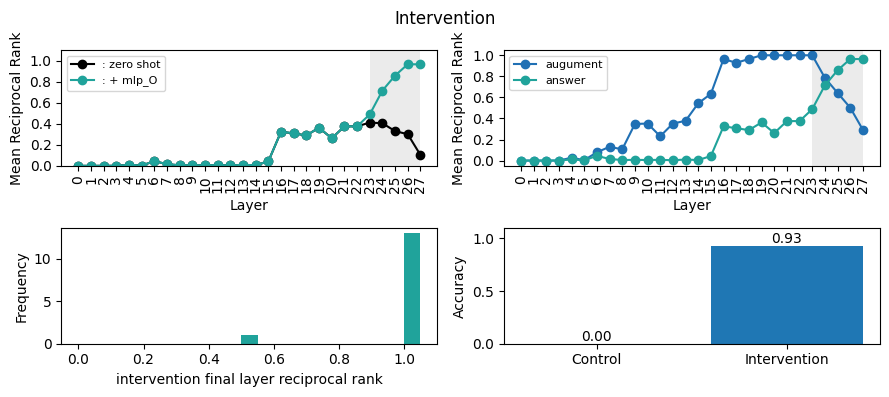

In [37]:
word_answers_color = [ " Red", " Blue", " Green", " Purple", " Yellow", " Orange", " Pink", " Brown", " Black", " White", " Gray", " Gold", " Silver", " Cardinal"]
word_args_color = [" red", " blue", " green", " purple", " yellow", " orange", " pink", " brown", " black", " white", " gray", " gold", " silver", " cardinal"]
print(f"mean over {len(word_answers_color)} runs")
plot_intervention_mean(wrapper, mlps, word_answers_color, word_args_color, 
    paper_o_upper.to(device), layer_start=23)

mean over 14 runs
final rrs below 0.95: [' cardinal']
final rrs above 0.95: [' red', ' blue', ' green', ' purple', ' yellow', ' orange', ' pink', ' brown', ' black', ' white', ' gray', ' gold', ' silver']
wrong interv words: [' cardinal']
correct interv words: [' red', ' blue', ' green', ' purple', ' yellow', ' orange', ' pink', ' brown', ' black', ' white', ' gray', ' gold', ' silver']


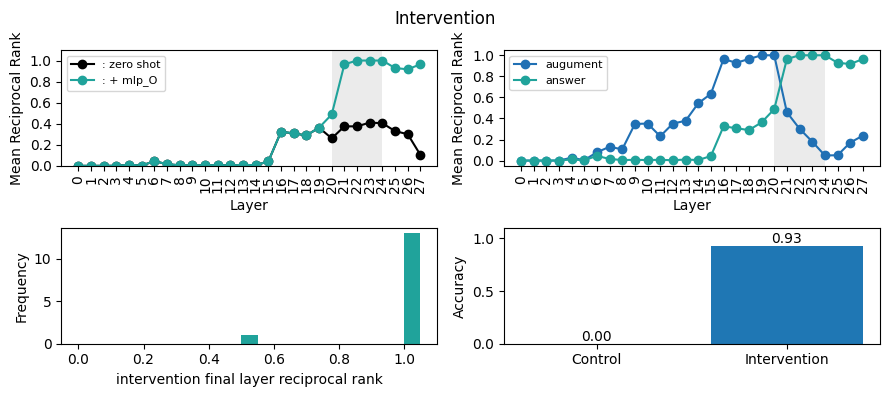

In [38]:
word_answers_color = [ " Red", " Blue", " Green", " Purple", " Yellow", " Orange", " Pink", " Brown", " Black", " White", " Gray", " Gold", " Silver", " Cardinal"]
word_args_color = [" red", " blue", " green", " purple", " yellow", " orange", " pink", " brown", " black", " white", " gray", " gold", " silver", " cardinal"]
print(f"mean over {len(word_answers_color)} runs")
plot_intervention_mean(wrapper, mlps, word_answers_color, word_args_color, 
    mlp_O=paper_o_upper.to(device), layer_start=20, layer_end=25)

## mean total 

mean over 29 runs
final rrs below 0.95: [' cardinal', ' couch', ' cold', ' name', ' word', ' cup', ' man', ' bread', ' bus']
final rrs above 0.95: [' red', ' blue', ' green', ' purple', ' yellow', ' orange', ' pink', ' brown', ' black', ' white', ' gray', ' gold', ' silver', ' top', ' girl', ' hello', ' king', ' fruit', ' music', ' milk']
wrong interv words: [' cardinal', ' couch', ' cold', ' name', ' word', ' cup', ' man', ' bread', ' bus']
correct interv words: [' red', ' blue', ' green', ' purple', ' yellow', ' orange', ' pink', ' brown', ' black', ' white', ' gray', ' gold', ' silver', ' top', ' girl', ' hello', ' king', ' fruit', ' music', ' milk']


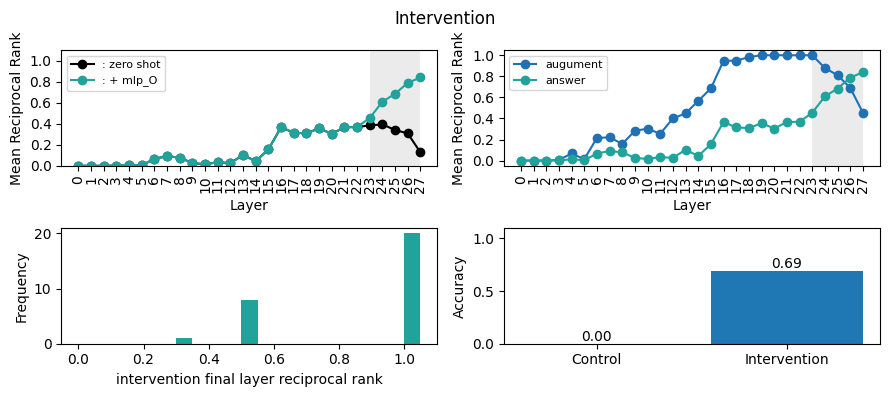

In [39]:
word_answers_total = word_answers_color + word_answers
word_args_total = word_args_color + word_args
print(f"mean over {len(word_answers_total)} runs")
plot_intervention_mean(wrapper, mlps, word_answers_total, word_args_total,
     mlp_O=paper_o_upper.to(device), layer_start=23)

mean over 29 runs
final rrs below 0.95: [' cardinal', ' name', ' man']
final rrs above 0.95: [' red', ' blue', ' green', ' purple', ' yellow', ' orange', ' pink', ' brown', ' black', ' white', ' gray', ' gold', ' silver', ' couch', ' top', ' girl', ' cold', ' hello', ' word', ' cup', ' king', ' fruit', ' music', ' bread', ' milk', ' bus']
wrong interv words: [' cardinal', ' name', ' man']
correct interv words: [' red', ' blue', ' green', ' purple', ' yellow', ' orange', ' pink', ' brown', ' black', ' white', ' gray', ' gold', ' silver', ' couch', ' top', ' girl', ' cold', ' hello', ' word', ' cup', ' king', ' fruit', ' music', ' bread', ' milk', ' bus']


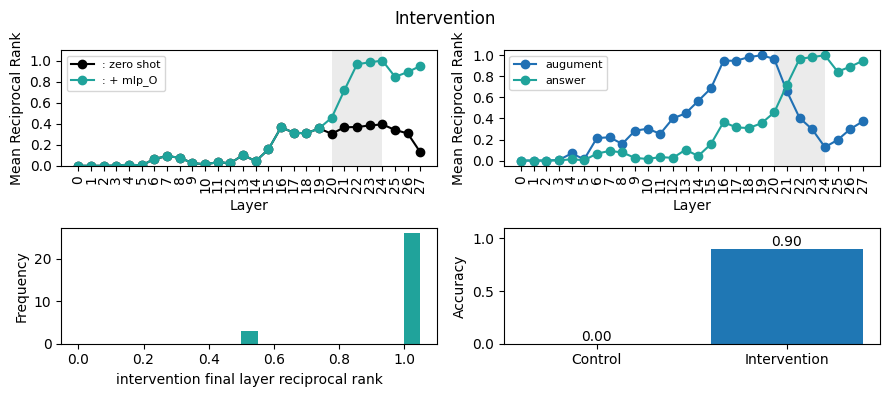

In [40]:
word_answers_total = word_answers_color + word_answers
word_args_total = word_args_color + word_args
print(f"mean over {len(word_answers_total)} runs")
plot_intervention_mean(wrapper, mlps, word_answers_total, word_args_total,
     mlp_O=paper_o_upper.to(device), layer_start=20, layer_end=25)

# past tense

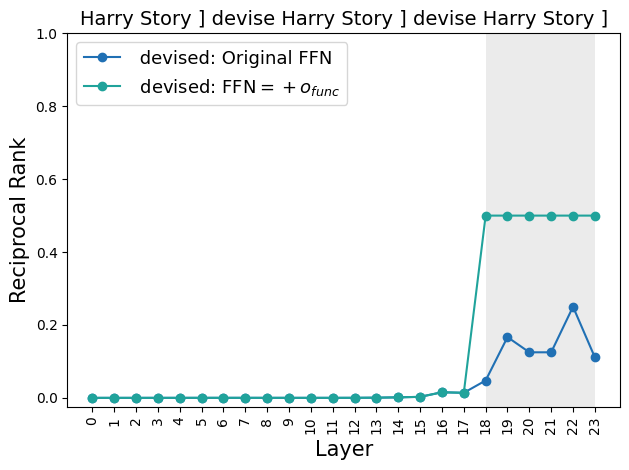

In [18]:
"""
Lastly, we can use a similar update to promote past tense verbs. We find that this update promotes past tensing 
in general, but doesn't promote the past tense verb all the way to to the top of the distribution as often
(only about 8% of the time).
"""
reset_mlps()
pt1 = "Today I abandon. Yesterday I abandoned. Today I abolish. Yesterday I"
pt_ids, pt_toks = tokenize(pt1)
pt_logits=wrapper.get_layers(pt_ids)
o_past = wrapper.model.activations_['mlp_18']

pt_text  = "Harry Story ] devise Harry Story ] devise Harry Story ]"
pt_ids, pt_toks = tokenize(pt_text)

reset_mlps()
cntrl_pt_logits = wrapper.get_layers(pt_ids)
cntrl_rrs = wrapper.rr_per_layer(cntrl_pt_logits, ' devised')

#paper_o_past = torch.tensor(np.load('ovectors/gpt2medium/regular_past_o18_gpt2-medium.npy')).squeeze(0)
o_intervention(o_past.unsqueeze(0), layer_idx)

interv_pt_logits = wrapper.get_layers(pt_ids)
interv_rrs = wrapper.rr_per_layer(interv_pt_logits, ' devised')

plot_rrs_before_and_after_intervention(cntrl_rrs, interv_rrs, pt_text, " devised", line_idx=layer_idx)